In [1]:
# future idea: color by security issue date, transaction date
# future idea: with coupon 
# future idea: get rates from nbs.rs
# idea: median line graph

In [2]:
# Update manually based on nbs.rs
rates = {"Deposit facility rate": 4.5, "Reference rate": 5.75, "Lending facility rate": 7}

In [3]:
# Get belex.rs and javnidug.gov.rs data (stats, graphs, trades, issues)
import requests, time, json, csv, os
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from datetime import datetime
from io import StringIO
import pandas as pd


def fetch(url):
    if url not in cache:
        time.sleep(0.1)

        cache[url] = requests.get(url, headers={"User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/118.0.0.0 Safari/537.36"
        )}, verify=False).text # WARNING: https not working correctly
    
    return cache[url]


os.makedirs('plots', exist_ok=True)

with open("cache.json", "r") as file:
    cache = json.load(file)
    cache_size = len(cache)

stats, graphs, trades = [], [], []

issues_html = BeautifulSoup(fetch("https://javnidug.gov.rs/en/jpoziv"), "html.parser")    
issues = json.loads(issues_html.find(id="calendarComponent")["data-dates"])

assets_html = fetch("https://belex.rs/trgovanje/dnevni/prime/obv")

for link in BeautifulSoup(assets_html, "html.parser").select("#content table a"):
    name = link.get_text(strip=True)

    stats_html = fetch(f"https://belex.rs/trgovanje/hartija/dnevni/{name}")
    stats_obj = {"name": name}

    for table in BeautifulSoup(stats_html, "html.parser").find_all("table"):
        data = [[cell.get_text(strip=True) for cell in row.find_all(["td", "th"])] for row in table.find_all("tr")]
        
        if "podaci" not in data[0][0]:
            continue

        if data[0][0].startswith("Dnevni podaci"):
            stats_obj["Datum"] = data[0][0].replace("Dnevni podaci ", "")

        for row in data[1:]:
            stats_obj[row[0]] = row[1]
    
    stats.append(stats_obj)

    graphs_json = fetch(f"https://belex.rs/json/hartija.php?s={name}&p=3y&t=line")

    for graph in json.loads(graphs_json)["dataProvider"]:
        graphs.append({"name": name} | graph)
    
    trades_csv = fetch(f"https://belex.rs/xml/istorijski_csv.php?simbol={name}&lang=srb")

    if 'Nema istorijskih podataka' not in trades_csv:
        for trade in csv.DictReader(StringIO(trades_csv), delimiter=";"):
            trades.append({"name": name} | trade)
    
if len(cache) > cache_size:
    with open("cache.json", "w") as file:
        json.dump(cache, file, ensure_ascii=False, indent=2)

stats_raw_df = pd.DataFrame(stats)
graphs_raw_df = pd.DataFrame(graphs) 
trades_raw_df = pd.DataFrame(trades)
issues_raw_df = pd.DataFrame(issues)

In [4]:
# Stage 1: Data cleaning - make raw data user-friendly
def calc_years_apy(now_str, due_str, price):
    now = datetime.strptime(now_str.strip("."), "%d.%m.%Y").date()
    due = datetime.strptime(due_str.strip("."), "%d.%m.%Y").date()
    days = (due - now).days
    years = days / 365.25
    apy = 100 * ((100 / price) ** (1 / years) - 1)
    return years, apy

maturity_postfix = {"Г": 1, "М": 1 / 12, "Н": 7 / 365.25}

# Clean issues data
issues_df = (issues_raw_df
    .dropna(subset=['coupon', 'maturity', 'currency_eng'])
    .assign(
        coupon_rate=lambda x: pd.to_numeric(x['coupon'].str.replace(',', '.'), errors='coerce'),
        maturity_num=lambda x: pd.to_numeric(x['maturity'].str[:-1], errors='coerce'),
        maturity_unit=lambda x: x['maturity'].str[-1],
        maturity_years=lambda x: x['maturity_num'] * x['maturity_unit'].map(maturity_postfix),
        currency=lambda x: x['currency_eng']
    )
    .dropna(subset=['coupon_rate', 'maturity_years'])
)

# Clean stats data
stats_df = (stats_raw_df
    .assign(
        price=lambda x: pd.to_numeric(x['Cena'].str.replace(',', '.'), errors='coerce'),
        due_date=lambda x: x['Datum dospeća'],
        trade_date=lambda x: x['Datum'],
        inclusion_date=lambda x: x['Datum uključenja'],
        coupon_info=lambda x: x['Kupon/Kamatna stopa']
    )
    .dropna(subset=['price', 'due_date', 'trade_date'])
)

# Clean graphs data
graphs_df = (graphs_raw_df
    .assign(
        price=lambda x: pd.to_numeric(x['bv'].str.replace(',', '.'), errors='coerce'),
        volume=lambda x: pd.to_numeric(x['bo'].str.replace('.', '', regex=False), errors='coerce'),
        date=lambda x: x['vd']
    )
    .query('volume > 0')
    .dropna(subset=['price', 'volume', 'date'])
)

In [5]:
# Stage 2: Calculate plot-ready metrics

# Issues plot data - coupon-based APY
issues_plot_df = (issues_df
    .assign(
        years=lambda x: x['maturity_years'],
        apy=lambda x: x['coupon_rate']
    )
    .sort_values('years')
)

# RSRE-specific cleaned data
rsre_stats_df = stats_df[stats_df['name'].str.startswith('RSRE')]
rsre_graphs_df = graphs_df[graphs_df['name'].str.startswith('RSRE')]

# RSRE trades with APY calculations
rsre_trades_data = []
for _, stat in rsre_stats_df.iterrows():
    name = stat['name']
    due_date = stat['due_date']
    
    name_graphs = rsre_graphs_df[rsre_graphs_df['name'] == name]
    for _, graph in name_graphs.iterrows():
        years, apy = calc_years_apy(graph['date'], due_date, graph['price'])
        volume_value = graph['price'] * graph['volume']
        rsre_trades_data.append({'years': years, 'apy': apy, 'volume': volume_value})

rsre_trades_plot_df = pd.DataFrame(rsre_trades_data)

if not rsre_trades_plot_df.empty:
    vmin, vmax = rsre_trades_plot_df['volume'].min(), rsre_trades_plot_df['volume'].max()
    rsre_trades_plot_df['size'] = 50 * (rsre_trades_plot_df['volume'] - vmin) / (vmax - vmin)

# Current RSRE APY calculations
rsre_current_apy_df = (rsre_stats_df
    .assign(
        years=lambda x: x.apply(lambda row: calc_years_apy(row['trade_date'], row['due_date'], row['price'])[0], axis=1),
        apy=lambda x: x.apply(lambda row: calc_years_apy(row['trade_date'], row['due_date'], row['price'])[1], axis=1)
    )
    .sort_values('years')
)

# Short-term RSRE analysis
short_term_rsre_df = (rsre_stats_df
    .assign(
        years=lambda x: x.apply(lambda row: calc_years_apy(row['trade_date'], row['due_date'], row['price'])[0], axis=1),
        inception_month=lambda x: x['inclusion_date'].str[3:-1]
    )
    .query('years < 0.6')
)

# Monthly volume analysis
short_term_graphs_df = (rsre_graphs_df[rsre_graphs_df['name'].isin(short_term_rsre_df['name'])]
    .assign(
        month=lambda x: x['date'].str[3:],
        volume_value=lambda x: x['price'] * x['volume']
    )
)

volume_by_month = short_term_graphs_df.groupby('month')['volume_value'].sum() / 1_000_000
days_by_month = short_term_graphs_df.groupby('month')['date'].nunique()

all_months = sorted(set(volume_by_month.index) | set(days_by_month.index), 
                   key=lambda d: datetime.strptime(d, "%m.%Y"))

volumes_by_month = [volume_by_month.get(m, 0) for m in all_months]
trades_by_month = [days_by_month.get(m, 0) for m in all_months]

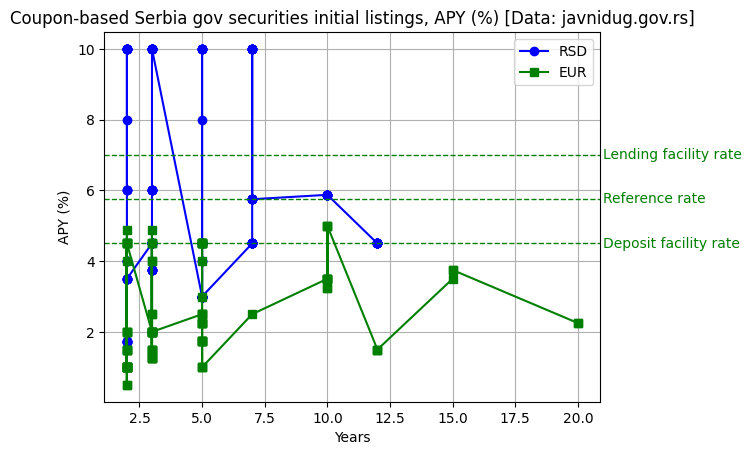

In [6]:
# Plot coupon-based initals APY
for currency, (color, marker) in [('RSD', ('blue', 'o')), ('EUR', ('green', 's'))]:
    data = issues_plot_df[issues_plot_df['currency'] == currency]
    if not data.empty:
        plt.plot(data['years'], data['apy'], marker=marker, label=currency, color=color)

all_years = issues_plot_df['years']
for label, yline in rates.items():
    plt.axhline(y=yline, color="green", linestyle="--", linewidth=1)
    plt.text(all_years.max() + 1, yline, label, verticalalignment="center", color="green")

plt.xlabel("Years")
plt.ylabel("APY (%)")
plt.title("Coupon-based Serbia gov securities initial listings, APY (%) [Data: javnidug.gov.rs]")
plt.grid(True)
plt.legend()
plt.savefig('plots/coupon_based_apy.jpg', dpi=300, bbox_inches='tight')
plt.show()

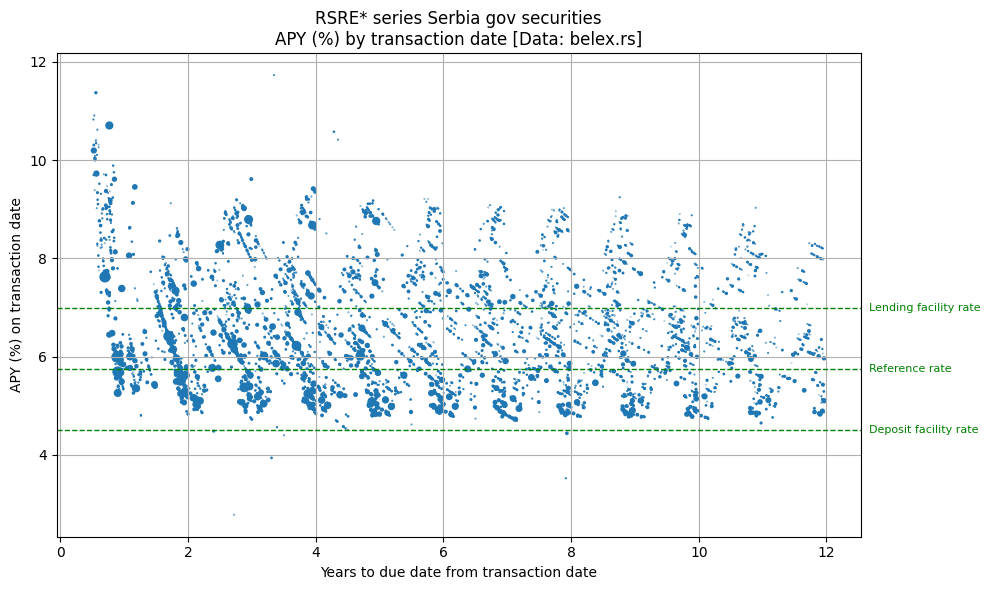

In [7]:
# Plot RSRE trades
fig, ax = plt.subplots(figsize=(10, 6))

for label, yline in rates.items():
    plt.axhline(y=yline, color="green", linestyle="--", linewidth=1)
    plt.text(rsre_trades_plot_df['years'].max() + 0.7, yline, label, va="center", color="green", fontsize=8)

ax.scatter(rsre_trades_plot_df['years'], rsre_trades_plot_df['apy'], s=rsre_trades_plot_df['size'], marker="o")
plt.xlabel("Years to due date from transaction date")
plt.ylabel("APY (%) on transaction date")
plt.title("RSRE* series Serbia gov securities\nAPY (%) by transaction date [Data: belex.rs]")
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/rsre_trades.jpg', dpi=300, bbox_inches='tight')
plt.show()

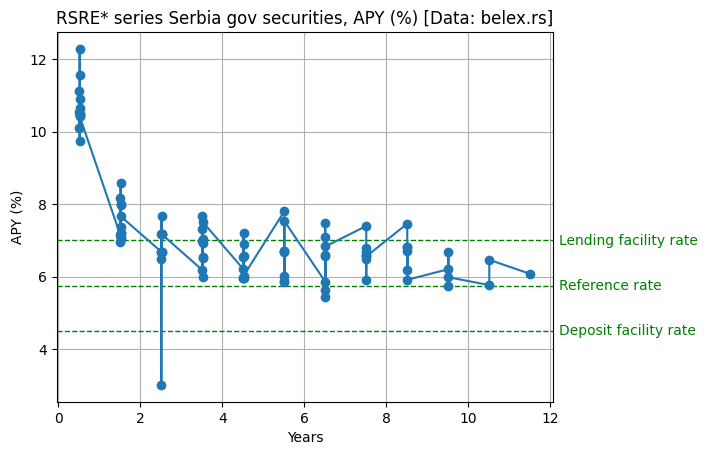

In [8]:
# Plot RSRE current APY using DataFrame
kupon_check = set(rsre_current_apy_df['coupon_info'].dropna())
if kupon_check != {"bez kupona"}:
    raise ValueError("Invalid coupon")

for label, yline in rates.items():
    plt.axhline(y=yline, color="green", linestyle="--", linewidth=1)
    plt.text(rsre_current_apy_df['years'].max() + 0.7, yline, label, verticalalignment="center", color="green")

plt.plot(rsre_current_apy_df['years'], rsre_current_apy_df['apy'], marker="o")
plt.xlabel("Years")
plt.ylabel("APY (%)")
plt.title("RSRE* series Serbia gov securities, APY (%) [Data: belex.rs]")
plt.grid(True)
plt.savefig('plots/rsre_current_apy.jpg', dpi=300, bbox_inches='tight')
plt.show()

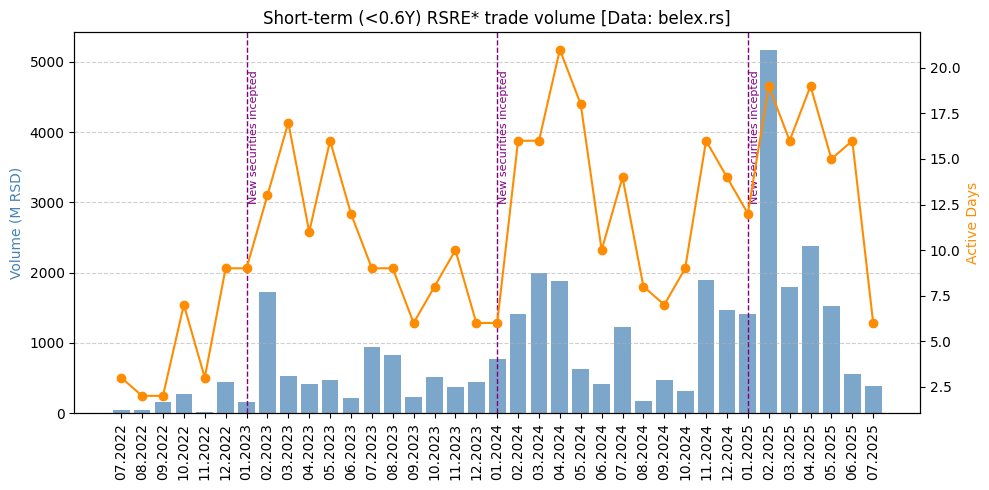

In [9]:
# Plot trade volume and transaction count using DataFrame
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(all_months, volumes_by_month, color='steelblue', label='Volume (M RSD)', alpha=0.7)
line, = ax2.plot(all_months, trades_by_month, color='darkorange', marker='o', label='Active Days')

ax1.set_ylabel("Volume (M RSD)", color='steelblue')
ax2.set_ylabel("Active Days", color='darkorange')
ax1.set_title("Short-term (<0.6Y) RSRE* trade volume [Data: belex.rs]")

ax1.set_xticks(range(len(all_months)))
ax1.set_xticklabels(all_months, rotation=90)
ax1.grid(axis='y', linestyle='--', alpha=0.6)

for month in short_term_rsre_df['inception_month'].dropna().unique():
    if month in all_months:
        xpos = all_months.index(month)
        ax1.axvline(x=xpos, color="purple", linestyle="--", linewidth=1)
        ax1.text(xpos + 0.1, ax1.get_ylim()[1] * 0.9, "New securities incepted",
                rotation=90, verticalalignment="top", color="purple", fontsize=8)

plt.tight_layout()
plt.savefig('plots/short_term_rsre_volume.jpg', dpi=300, bbox_inches='tight')
plt.show()